# Wykonanie metryk (IoU) względem Ground Truth

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib.axes import Axes
import re
from PIL import Image


# Dodanie dźwięku przy długich komórkach
import subprocess
def play_sound():
    sound_file = '/mnt/d/Backup/INZ/msg.ogg'
    subprocess.run(['ffplay', '-nodisp', '-autoexit', sound_file], capture_output=True)

## Przygotowanie i obróbka danych

### Pobranie danych

In [3]:
DATA_PATH = Path('/mnt/d/Backup/MAGISTERSKIE/outputs')

Ścieżki do pliku

In [4]:
df = pd.read_csv(DATA_PATH / 'GDSAM_2000/df.csv')
color_paths = df.loc[:,"color_path"]
color_paths_for_llms = df.loc[20:119,"color_path"]

In [5]:
# Pobierz rozmiar pierwsze obrazu (wszystkie są jednakowe)
first_path = color_paths.iloc[0]
img = Image.open(first_path)
IMAGE_WIDTH, IMAGE_HEIGHT = img.size

print(f"Rozmiar obrazu: {IMAGE_WIDTH} x {IMAGE_HEIGHT}")

Rozmiar obrazu: 512 x 424


Ground Truth

In [6]:
ground_truth_bbox = np.load(DATA_PATH / 'GT/bboxes_normalized_2000.npy')
print(ground_truth_bbox.shape)

(2012, 12)


GroundedSAM

In [7]:
GroundedSAM_bbox = np.load(DATA_PATH / 'GDSAM_2000/all_boxes.npy')
print(GroundedSAM_bbox.shape)

(2012, 3, 4)


OpenAI

In [8]:
gpt_bbox = np.load(DATA_PATH / 'LLM/xy_array_gpt100.npy')
print(gpt_bbox.shape)

(100,)


Dostrojone OpenAI

In [9]:
gpt_ft_bbox = np.load(DATA_PATH / 'LLM/xy_array_gpt_ft.npy')
print(gpt_ft_bbox.shape)
# for i in range(0,10):print(f"ID {i}: {gpt_bbox[i]}\n")

(100,)


### Dopasowanie wszystkich do tego samego formatu

Widok wszystkich po pobraniu

In [10]:
i = 12
print(f"ground_truth_bbox: {ground_truth_bbox[i]}\n")
print(f"GroundedSAM_bbox: {GroundedSAM_bbox[i]}\n")
print(f"gpt_bbox: {gpt_bbox[i]}\n")
print(f"gpt_ft_bbox: {gpt_ft_bbox[i]}")

ground_truth_bbox: [0.31054688 0.2995283  0.35742188 0.3773585  0.35742188 0.25707546
 0.41992188 0.30660376 0.4375     0.3301887  0.45703125 0.41509435]

GroundedSAM_bbox: [[0.3013275  0.29014584 0.36623523 0.38551801]
 [0.35192299 0.25033733 0.42847854 0.31480581]
 [0.40702486 0.3132239  0.47420478 0.42812437]]

gpt_bbox: (0.285000,0.360000,0.335000,0.520000),(0.318000,0.300000,0.345000,0.360000),(0.365000,0.360000,0.445000,0.520000)

gpt_ft_bbox: (0.238281,0.396226,0.259766,0.452830),(0.271484,0.424528,0.300781,0.452830),(0.275391,0.452830,0.314453,0.490566)


Dopasowywanie OpenAI

In [11]:
def parse_bbox_rows(arr):
  out = []
  for row in arr:
    text = row[0] if isinstance(row, (list, np.ndarray)) else str(row)
    boxes = re.findall(r'\(([0-9]*\.?[0-9]+)\s*,\s*([0-9]*\.?[0-9]+)\s*,\s*([0-9]*\.?[0-9]+)\s*,\s*([0-9]*\.?[0-9]+)\)', text)
    nums = [float(x) for b in boxes for x in b]
    # dociecie/padding do 12 liczb (3 boxy po 4)
    if len(nums) < 12:
      nums += [0.0] * (12 - len(nums))
    else:
      nums = nums[:12]
    out.append(nums)
  return np.array(out, dtype=float)

gpt_bbox = parse_bbox_rows(gpt_bbox)
gpt_ft_bbox = parse_bbox_rows(gpt_ft_bbox)

print(f"OpenAI bbox shape: {gpt_bbox.shape}")
print(f"Przykład OpenAI bbox (pierwszy wiersz): \n{gpt_bbox[0]}\n")

print(f"Dostrojony OpenAI bbox shape: {gpt_ft_bbox.shape}")
print(f"Przykład dostrojonego OpenAI bbox (pierwszy wiersz): \n{gpt_ft_bbox[0]}")

OpenAI bbox shape: (100, 12)
Przykład OpenAI bbox (pierwszy wiersz): 
[0.4   0.38  0.46  0.6   0.354 0.3   0.392 0.38  0.47  0.42  0.54  0.62 ]

Dostrojony OpenAI bbox shape: (100, 12)
Przykład dostrojonego OpenAI bbox (pierwszy wiersz): 
[0.289062 0.396226 0.328125 0.481132 0.345703 0.396226 0.388672 0.433962
 0.353516 0.45283  0.396484 0.509434]


Dopasowywanie GroundedSAM

In [12]:
GroundedSAM_bbox = GroundedSAM_bbox.reshape(-1,12)

Stworzenie GDSAM i ground truth dla 100 obrazów testowych

In [13]:
GroundedSAM_bbox_100 = GroundedSAM_bbox[20:120]
ground_truth_bbox_100 = ground_truth_bbox[20:120]

Wyświetlenie wyników dopasowywania

In [14]:
i = 12
print(f"ground_truth_bbox: {ground_truth_bbox.shape} -> {ground_truth_bbox[i]}\n")
print(f"ground_truth_bbox_100: {ground_truth_bbox_100.shape} -> {ground_truth_bbox_100[i]}\n")
print(f"GroundedSAM_bbox: {GroundedSAM_bbox.shape} -> {GroundedSAM_bbox[i]}\n")
print(f"GroundedSAM_bbox_100: {GroundedSAM_bbox_100.shape} -> {GroundedSAM_bbox_100[i]}\n")
print(f"gpt_bbox: {gpt_bbox.shape} -> {gpt_bbox[i]}\n")
print(f"gpt_ft_bbox: {gpt_ft_bbox.shape} -> {gpt_ft_bbox[i]}")

ground_truth_bbox: (2012, 12) -> [0.31054688 0.2995283  0.35742188 0.3773585  0.35742188 0.25707546
 0.41992188 0.30660376 0.4375     0.3301887  0.45703125 0.41509435]

ground_truth_bbox_100: (100, 12) -> [0.23242188 0.4292453  0.26171875 0.4787736  0.2578125  0.41509435
 0.28515625 0.46698114 0.26171875 0.48349056 0.3203125  0.5283019 ]

GroundedSAM_bbox: (2012, 12) -> [0.3013275  0.29014584 0.36623523 0.38551801 0.35192299 0.25033733
 0.42847854 0.31480581 0.40702486 0.3132239  0.47420478 0.42812437]

GroundedSAM_bbox_100: (100, 12) -> [0.22168809 0.41595042 0.26852518 0.49022976 0.24849398 0.40516564
 0.29193011 0.47497877 0.2501969  0.46269608 0.32457122 0.54319108]

gpt_bbox: (100, 12) -> [0.285 0.36  0.335 0.52  0.318 0.3   0.345 0.36  0.365 0.36  0.445 0.52 ]

gpt_ft_bbox: (100, 12) -> [0.238281 0.396226 0.259766 0.45283  0.271484 0.424528 0.300781 0.45283
 0.275391 0.45283  0.314453 0.490566]


## Obliczanie metryk

In [15]:
i = 12
print(f"ground_truth_bbox: {ground_truth_bbox.shape} -> {ground_truth_bbox[i]}\n")
print(f"ground_truth_bbox_100: {ground_truth_bbox_100.shape} -> {ground_truth_bbox_100[i]}\n")
print(f"GroundedSAM_bbox: {GroundedSAM_bbox.shape} -> {GroundedSAM_bbox[i]}\n")
print(f"GroundedSAM_bbox_100: {GroundedSAM_bbox_100.shape} -> {GroundedSAM_bbox_100[i]}\n")
print(f"gpt_bbox: {gpt_bbox.shape} -> {gpt_bbox[i]}\n")
print(f"gpt_ft_bbox: {gpt_ft_bbox.shape} -> {gpt_ft_bbox[i]}")

ground_truth_bbox: (2012, 12) -> [0.31054688 0.2995283  0.35742188 0.3773585  0.35742188 0.25707546
 0.41992188 0.30660376 0.4375     0.3301887  0.45703125 0.41509435]

ground_truth_bbox_100: (100, 12) -> [0.23242188 0.4292453  0.26171875 0.4787736  0.2578125  0.41509435
 0.28515625 0.46698114 0.26171875 0.48349056 0.3203125  0.5283019 ]

GroundedSAM_bbox: (2012, 12) -> [0.3013275  0.29014584 0.36623523 0.38551801 0.35192299 0.25033733
 0.42847854 0.31480581 0.40702486 0.3132239  0.47420478 0.42812437]

GroundedSAM_bbox_100: (100, 12) -> [0.22168809 0.41595042 0.26852518 0.49022976 0.24849398 0.40516564
 0.29193011 0.47497877 0.2501969  0.46269608 0.32457122 0.54319108]

gpt_bbox: (100, 12) -> [0.285 0.36  0.335 0.52  0.318 0.3   0.345 0.36  0.365 0.36  0.445 0.52 ]

gpt_ft_bbox: (100, 12) -> [0.238281 0.396226 0.259766 0.45283  0.271484 0.424528 0.300781 0.45283
 0.275391 0.45283  0.314453 0.490566]


### IoU

Wykonanie metryki IoU dla GroundedSAM i 2000 plików

In [16]:
def box_iou(box_a, box_b):
    """IoU dla dwóch boxów w formacie [x1, y1, x2, y2]."""
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter_area

    return 0.0 if union <= 0 else inter_area / union


def image_iou(gt_row, pred_row):
    """Średnie IoU dla jednego obrazu (boxy parowane po indeksie)."""
    gt_boxes = np.asarray(gt_row, dtype=float).reshape(-1, 4)
    pred_boxes = np.asarray(pred_row, dtype=float).reshape(-1, 4)

    valid_mask = np.array([
        (b[2] > b[0]) and (b[3] > b[1]) and np.any(b != 0.0)
        for b in gt_boxes
    ])

    if not valid_mask.any():
        return np.nan

    ious = [
        box_iou(gt_boxes[i], pred_boxes[i])
        for i in range(min(len(gt_boxes), len(pred_boxes)))
        if valid_mask[i]
    ]
    return float(np.mean(ious)) if ious else np.nan


def summarize_iou(iou_values, label):
    valid = iou_values[~np.isnan(iou_values)]
    print(f"\n--- {label} ---")
    print(f"Liczba próbek z poprawnym GT: {len(valid)}")
    if len(valid) == 0:
        print("Brak próbek do podsumowania.")
        return np.nan
    print(f"Średnie IoU: {valid.mean():.4f}")
    print(f"Mediana IoU: {np.median(valid):.4f}")
    print(f"Min/Max IoU: {valid.min():.4f} / {valid.max():.4f}")
    return valid.mean()


def to_excluded_indices(incomplete_detect, n):
    """Konwersja tablicy incomplete do zbioru indeksów 0-based do wykluczenia."""
    arr = np.asarray(incomplete_detect)

    if arr.dtype == bool:
        if arr.size != n:
            raise ValueError(
                f"Maska bool ma długość {arr.size}, a liczba próbek to {n}."
            )
        return set(np.where(arr)[0].tolist())

    flat = arr.reshape(-1)
    excluded = {int(x) for x in flat if np.isfinite(x)}
    excluded = {i for i in excluded if 0 <= i < n}
    return excluded


# IoU dla GroundedSAM na pełnym zbiorze
n = min(len(ground_truth_bbox), len(GroundedSAM_bbox))
iou_per_image_gdsam = np.array([
    image_iou(ground_truth_bbox[i], GroundedSAM_bbox[i])
    for i in range(n)
], dtype=float)

# Id z brakującą detekcją
incomplete_detect_GDSAM = np.load(DATA_PATH / 'GDSAM_2000/incomplete_detect.npy')
excluded_idx = to_excluded_indices(incomplete_detect_GDSAM, n)

# IoU po odfiltrowaniu incomplete id
keep_mask = np.array([i not in excluded_idx for i in range(n)], dtype=bool)
iou_per_image_gdsam_filtered = iou_per_image_gdsam[keep_mask]

print(f"Liczba wszystkich porównanych próbek: {n}")
print(f"Liczba id do wykluczenia (incomplete): {len(excluded_idx)}")
print(f"Liczba próbek po filtracji: {keep_mask.sum()}")

mean_full = summarize_iou(iou_per_image_gdsam, "GroundedSAM - pełny zbiór")
mean_filtered = summarize_iou(iou_per_image_gdsam_filtered, "GroundedSAM - bez incomplete id")

if np.isfinite(mean_full) and np.isfinite(mean_filtered):
    delta = mean_filtered - mean_full
    print(f"\nZmiana średniego IoU po filtracji: {delta:+.4f}")

# Podgląd pierwszych 10 IoU po filtracji
valid_filtered = iou_per_image_gdsam_filtered[~np.isnan(iou_per_image_gdsam_filtered)]
print("Pierwsze 10 IoU po filtracji:", np.round(valid_filtered[:10], 4))

Liczba wszystkich porównanych próbek: 2012
Liczba id do wykluczenia (incomplete): 291
Liczba próbek po filtracji: 1721

--- GroundedSAM - pełny zbiór ---
Liczba próbek z poprawnym GT: 1999
Średnie IoU: 0.4421
Mediana IoU: 0.4682
Min/Max IoU: 0.0000 / 0.6892

--- GroundedSAM - bez incomplete id ---
Liczba próbek z poprawnym GT: 1721
Średnie IoU: 0.4661
Mediana IoU: 0.4786
Min/Max IoU: 0.1308 / 0.6735

Zmiana średniego IoU po filtracji: +0.0240
Pierwsze 10 IoU po filtracji: [0.3635 0.4771 0.4597 0.4668 0.4485 0.4612 0.4898 0.5215 0.4889 0.5341]


In [17]:
# IoU dla zbiorów testowych (100 próbek): GroundedSAM, OpenAI, OpenAI FT
TEST_START, TEST_END = 20, 120  # zakres zgodny z *_100
GT_100 = ground_truth_bbox_100

def evaluate_iou_100(label, gt_arr, pred_arr, excluded_local_idx=None):
    n_local = min(len(gt_arr), len(pred_arr))
    iou_values = np.array([
        image_iou(gt_arr[i], pred_arr[i])
        for i in range(n_local)
    ], dtype=float)

    print(f"\n===== {label} (n={n_local}) =====")
    mean_full = summarize_iou(iou_values, f"{label} - pełny zbiór")

    rows = [
        {
            "label": label,
            "n": n_local,
            "excluded": 0,
            "mean_iou": mean_full,
        }
    ]

    if excluded_local_idx is not None and len(excluded_local_idx) > 0:
        keep_mask = np.array([i not in excluded_local_idx for i in range(n_local)], dtype=bool)
        iou_filtered = iou_values[keep_mask]
        mean_filtered = summarize_iou(iou_filtered, f"{label} - bez incomplete id")
        if np.isfinite(mean_full) and np.isfinite(mean_filtered):
            print(f"Zmiana średniego IoU po filtracji: {mean_filtered - mean_full:+.4f}")

        filtered_label = label.replace("GroundedSAM", "GroundedSAM_filtered", 1)
        rows.append(
            {
                "label": filtered_label,
                "n": int(keep_mask.sum()),
                "excluded": len(excluded_local_idx),
                "mean_iou": mean_filtered,
            }
        )

    return rows


# incomplete dla GroundedSAM na zakresie 100 (globalne id -> lokalne 0..99)
incomplete_detect_GDSAM = np.load(DATA_PATH / 'GDSAM_2000/incomplete_detect.npy')
excluded_global = to_excluded_indices(incomplete_detect_GDSAM, len(ground_truth_bbox))
excluded_local_100 = {i - TEST_START for i in excluded_global if TEST_START <= i < TEST_END}

results_100 = []
results_100.extend(
    evaluate_iou_100(
        "GroundedSAM_100", GT_100, GroundedSAM_bbox_100, excluded_local_100
    )
)
results_100.extend(evaluate_iou_100("OpenAI_100", GT_100, gpt_bbox))
results_100.extend(evaluate_iou_100("OpenAI_FT_100", GT_100, gpt_ft_bbox))

summary_100 = pd.DataFrame(results_100)
print("\nPodsumowanie IoU (100 próbek):")
display(summary_100)


===== GroundedSAM_100 (n=100) =====

--- GroundedSAM_100 - pełny zbiór ---
Liczba próbek z poprawnym GT: 100
Średnie IoU: 0.4736
Mediana IoU: 0.4846
Min/Max IoU: 0.1786 / 0.5743

--- GroundedSAM_100 - bez incomplete id ---
Liczba próbek z poprawnym GT: 98
Średnie IoU: 0.4749
Mediana IoU: 0.4860
Min/Max IoU: 0.1786 / 0.5743
Zmiana średniego IoU po filtracji: +0.0012

===== OpenAI_100 (n=100) =====

--- OpenAI_100 - pełny zbiór ---
Liczba próbek z poprawnym GT: 100
Średnie IoU: 0.0131
Mediana IoU: 0.0000
Min/Max IoU: 0.0000 / 0.2698

===== OpenAI_FT_100 (n=100) =====

--- OpenAI_FT_100 - pełny zbiór ---
Liczba próbek z poprawnym GT: 100
Średnie IoU: 0.1292
Mediana IoU: 0.0895
Min/Max IoU: 0.0000 / 0.5507

Podsumowanie IoU (100 próbek):


,label,n,excluded,mean_iou
0,GroundedSAM_100,100,0,0.473609
1,GroundedSAM_filtered_100,98,2,0.474852
2,OpenAI_100,100,0,0.013055
3,OpenAI_FT_100,100,0,0.129153


### Odległość od środka

Wykonanie metryki odległości środka (euklidesowej) pomiędzy referencją (Ground Truth) a predykcją.

In [18]:
# Odległość środka boxów: referencja (GT) vs predykcja
def box_center(box):
    """Środek boxa [x1, y1, x2, y2]."""
    x1, y1, x2, y2 = np.asarray(box, dtype=float)
    return np.array([(x1 + x2) / 2.0, (y1 + y2) / 2.0], dtype=float)


def box_center_distance(box_a, box_b):
    """Odległość euklidesowa między środkami dwóch boxów."""
    ca = box_center(box_a)
    cb = box_center(box_b)
    return float(np.linalg.norm(ca - cb))


def image_center_distance(gt_row, pred_row):
    """Średnia odległość środka dla jednego obrazu (boxy parowane po indeksie)."""
    gt_boxes = np.asarray(gt_row, dtype=float).reshape(-1, 4)
    pred_boxes = np.asarray(pred_row, dtype=float).reshape(-1, 4)

    valid_mask = np.array([
        (b[2] > b[0]) and (b[3] > b[1]) and np.any(b != 0.0)
        for b in gt_boxes
    ], dtype=bool)

    if not valid_mask.any():
        return np.nan

    dists = [
        box_center_distance(gt_boxes[i], pred_boxes[i])
        for i in range(min(len(gt_boxes), len(pred_boxes)))
        if valid_mask[i]
    ]
    return float(np.mean(dists)) if dists else np.nan


def summarize_center_distance(values, label):
    valid = values[~np.isnan(values)]
    print(f"\n--- {label} ---")
    print(f"Liczba próbek z poprawnym GT: {len(valid)}")
    if len(valid) == 0:
        print("Brak próbek do podsumowania.")
        return np.nan
    print(f"Średnia odległość: {valid.mean():.4f}")
    print(f"Mediana odległości: {np.median(valid):.4f}")
    print(f"Min/Max odległości: {valid.min():.4f} / {valid.max():.4f}")
    return valid.mean()


def evaluate_center_distance(label, gt_arr, pred_arr, excluded_local_idx=None):
    n_local = min(len(gt_arr), len(pred_arr))
    dist_values = np.array([
        image_center_distance(gt_arr[i], pred_arr[i])
        for i in range(n_local)
    ], dtype=float)

    print(f"\n===== {label} (n={n_local}) =====")
    mean_full = summarize_center_distance(dist_values, f"{label} - pełny zbiór")

    rows = [
        {
            "label": label,
            "n": n_local,
            "excluded": 0,
            "mean_distance": mean_full,
        }
    ]

    if excluded_local_idx is not None and len(excluded_local_idx) > 0:
        keep_mask = np.array([i not in excluded_local_idx for i in range(n_local)], dtype=bool)
        dist_filtered = dist_values[keep_mask]
        mean_filtered = summarize_center_distance(
            dist_filtered, f"{label} - bez incomplete id"
        )
        if np.isfinite(mean_full) and np.isfinite(mean_filtered):
            print(f"Zmiana średniej odległości po filtracji: {mean_filtered - mean_full:+.4f}")

        filtered_label = label.replace("GroundedSAM", "GroundedSAM_filtered", 1)
        rows.append(
            {
                "label": filtered_label,
                "n": int(keep_mask.sum()),
                "excluded": len(excluded_local_idx),
                "mean_distance": mean_filtered,
            }
        )

    return rows


results_center = []

# GroundedSAM: pełny zbiór (2000) + filtracja incomplete
excluded_idx_full = to_excluded_indices(incomplete_detect_GDSAM, len(ground_truth_bbox))
results_center.extend(
    evaluate_center_distance(
        "GroundedSAM_2000", ground_truth_bbox, GroundedSAM_bbox, excluded_idx_full
    )
)

# Zbiory testowe 100 próbek
results_center.extend(
    evaluate_center_distance(
        "GroundedSAM_100", ground_truth_bbox_100, GroundedSAM_bbox_100, excluded_local_100
    )
)
results_center.extend(
    evaluate_center_distance("OpenAI_100", ground_truth_bbox_100, gpt_bbox)
)
results_center.extend(
    evaluate_center_distance("OpenAI_FT_100", ground_truth_bbox_100, gpt_ft_bbox)
)

summary_center = pd.DataFrame(results_center)

# Zachowujemy jawnie kolumnę w pikselach dla czytelności raportu
image_diagonal = np.sqrt(IMAGE_WIDTH**2 + IMAGE_HEIGHT**2)
summary_center['mean_distance_px'] = summary_center['mean_distance'] * image_diagonal

print("\nPodsumowanie odległości środka [piksele]:")
display(summary_center[['label', 'n', 'excluded', 'mean_distance_px']])


===== GroundedSAM_2000 (n=2012) =====

--- GroundedSAM_2000 - pełny zbiór ---
Liczba próbek z poprawnym GT: 1999
Średnia odległość: 0.0352
Mediana odległości: 0.0054
Min/Max odległości: 0.0006 / 0.8183

--- GroundedSAM_2000 - bez incomplete id ---
Liczba próbek z poprawnym GT: 1721
Średnia odległość: 0.0072
Mediana odległości: 0.0050
Min/Max odległości: 0.0007 / 0.2187
Zmiana średniej odległości po filtracji: -0.0281

===== GroundedSAM_100 (n=100) =====

--- GroundedSAM_100 - pełny zbiór ---
Liczba próbek z poprawnym GT: 100
Średnia odległość: 0.0130
Mediana odległości: 0.0047
Min/Max odległości: 0.0025 / 0.2593

--- GroundedSAM_100 - bez incomplete id ---
Liczba próbek z poprawnym GT: 98
Średnia odległość: 0.0082
Mediana odległości: 0.0047
Min/Max odległości: 0.0025 / 0.2187
Zmiana średniej odległości po filtracji: -0.0049

===== OpenAI_100 (n=100) =====

--- OpenAI_100 - pełny zbiór ---
Liczba próbek z poprawnym GT: 100
Średnia odległość: 0.1285
Mediana odległości: 0.1269
Min/Max od

,label,n,excluded,mean_distance_px
0,GroundedSAM_2000,2012,0,23.427893
1,GroundedSAM_filtered_2000,1721,291,4.778191
2,GroundedSAM_100,100,0,8.672896
3,GroundedSAM_filtered_100,98,2,5.447442
4,OpenAI_100,100,0,85.422318
5,OpenAI_FT_100,100,0,41.154841


## Rozszerzona analiza metryk dla pracy magisterskiej

In [19]:
import matplotlib.pyplot as plt
from scipy import stats

# === CZĘŚĆ 1: Rozbudowana statystyka dla IoU ===
print("=" * 80)
print("ROZBUDOWANA STATYSTYKA IoU")
print("=" * 80)

# IoU dla pełnego zbioru 2000 - bez filtru
iou_gdsam_2000_all = iou_per_image_gdsam[~np.isnan(iou_per_image_gdsam)]

# IoU dla pełnego zbioru 2000 - z filtrem (incomplete removed)
iou_gdsam_filtered = iou_per_image_gdsam_filtered[~np.isnan(iou_per_image_gdsam_filtered)]

# IoU dla zbiorów testowych 100
iou_gdsam_100 = np.array([
    image_iou(ground_truth_bbox_100[i], GroundedSAM_bbox_100[i])
    for i in range(len(ground_truth_bbox_100))
], dtype=float)
iou_gdsam_100_valid = iou_gdsam_100[~np.isnan(iou_gdsam_100)]

iou_gpt_100 = np.array([
    image_iou(ground_truth_bbox_100[i], gpt_bbox[i])
    for i in range(len(ground_truth_bbox_100))
], dtype=float)
iou_gpt_100_valid = iou_gpt_100[~np.isnan(iou_gpt_100)]

iou_gpt_ft_100 = np.array([
    image_iou(ground_truth_bbox_100[i], gpt_ft_bbox[i])
    for i in range(len(ground_truth_bbox_100))
], dtype=float)
iou_gpt_ft_100_valid = iou_gpt_ft_100[~np.isnan(iou_gpt_ft_100)]

# Funkcja do obliczania rozszerzonej statystyki
def extended_stats(values, label):
    """Oblicza rozszerzone statystyki dla zbioru wartości."""
    valid = values[~np.isnan(values)]
    if len(valid) == 0:
        return None

    stats_dict = {
        "Label": label,
        "n": len(valid),
        "Mean": valid.mean(),
        "Std": valid.std(),
        "Median": np.median(valid),
        "Q25": np.percentile(valid, 25),
        "Q75": np.percentile(valid, 75),
        "Min": valid.min(),
        "Max": valid.max(),
    }
    return stats_dict

# Zbierz statystyki IoU - UJEDNOLICONA TABELA
iou_stats_list = [
    extended_stats(iou_gdsam_2000_all, "GroundedSAM (2000 - all)"),
    extended_stats(iou_gdsam_filtered, "GroundedSAM (2000 - filtered)"),
    extended_stats(iou_gdsam_100_valid, "GroundedSAM (100)"),
    extended_stats(iou_gpt_100_valid, "OpenAI (100)"),
    extended_stats(iou_gpt_ft_100_valid, "OpenAI_FT (100)"),
]
iou_stats_df = pd.DataFrame([s for s in iou_stats_list if s is not None])
print("\nHistogramy metryk IoU - PORÓWNANIE:")
display(iou_stats_df.round(4))

# Analiza różnicy między filtrowanymi a wszystkimi dla 2000
print("\n" + "-" * 80)
print("ANALIZA WPŁYWU FILTRACJI (GroundedSAM 2000):")
print("-" * 80)
diff_iou = iou_gdsam_filtered.mean() - iou_gdsam_2000_all.mean()
print(f"Średnie IoU (wszystkie): {iou_gdsam_2000_all.mean():.4f} (n={len(iou_gdsam_2000_all)})")
print(f"Średnie IoU (filtered):  {iou_gdsam_filtered.mean():.4f} (n={len(iou_gdsam_filtered)})")
print(f"Zmiana po filtracji:     {diff_iou:+.4f} ({diff_iou/iou_gdsam_2000_all.mean()*100:+.1f}%)")
print(f"Liczba usunięto próbek:  {len(iou_gdsam_2000_all) - len(iou_gdsam_filtered)}")

# === CZĘŚĆ 2: Rozbudowana statystyka dla Center Distance ===
print("\n" + "=" * 80)
print("ROZBUDOWANA STATYSTYKA CENTER DISTANCE")
print("=" * 80)

# Oblicz dystanse dla 2000 - wszystkie i filtered
dist_gdsam_2000 = np.array([
    image_center_distance(ground_truth_bbox[i], GroundedSAM_bbox[i])
    for i in range(min(len(ground_truth_bbox), len(GroundedSAM_bbox)))
], dtype=float)
dist_gdsam_2000_valid = dist_gdsam_2000[~np.isnan(dist_gdsam_2000)]

# Filtered version (exclude incomplete)
dist_gdsam_2000_filtered = dist_gdsam_2000[keep_mask]
dist_gdsam_2000_filtered_valid = dist_gdsam_2000_filtered[~np.isnan(dist_gdsam_2000_filtered)]

# Oblicz dystanse dla 100 próbek
dist_gdsam_100 = np.array([
    image_center_distance(ground_truth_bbox_100[i], GroundedSAM_bbox_100[i])
    for i in range(len(ground_truth_bbox_100))
], dtype=float)
dist_gdsam_100_valid = dist_gdsam_100[~np.isnan(dist_gdsam_100)]

dist_gpt_100 = np.array([
    image_center_distance(ground_truth_bbox_100[i], gpt_bbox[i])
    for i in range(len(ground_truth_bbox_100))
], dtype=float)
dist_gpt_100_valid = dist_gpt_100[~np.isnan(dist_gpt_100)]

dist_gpt_ft_100 = np.array([
    image_center_distance(ground_truth_bbox_100[i], gpt_ft_bbox[i])
    for i in range(len(ground_truth_bbox_100))
], dtype=float)
dist_gpt_ft_100_valid = dist_gpt_ft_100[~np.isnan(dist_gpt_ft_100)]

# Konwersja na piksele
dist_gdsam_2000_px = dist_gdsam_2000_valid * image_diagonal
dist_gdsam_2000_filtered_px = dist_gdsam_2000_filtered_valid * image_diagonal
dist_gdsam_100_px = dist_gdsam_100_valid * image_diagonal
dist_gpt_100_px = dist_gpt_100_valid * image_diagonal
dist_gpt_ft_100_px = dist_gpt_ft_100_valid * image_diagonal

dist_stats_list = [
    extended_stats(dist_gdsam_2000, "GroundedSAM (2000) [normalized]"),
    extended_stats(dist_gdsam_2000_filtered, "GroundedSAM (2000 filtered) [normalized]"),
    extended_stats(dist_gdsam_100, "GroundedSAM (100) [normalized]"),
    extended_stats(dist_gpt_100, "OpenAI (100) [normalized]"),
    extended_stats(dist_gpt_ft_100, "OpenAI_FT (100) [normalized]"),
]
dist_stats_df = pd.DataFrame([s for s in dist_stats_list if s is not None])
dist_stats_px_df = dist_stats_df.copy()
for col in ['Mean', 'Std', 'Median', 'Q25', 'Q75', 'Min', 'Max']:
    dist_stats_px_df[col] = dist_stats_px_df[col] * image_diagonal
dist_stats_px_df['Label'] = dist_stats_px_df['Label'].str.replace('[normalized]', '[px]', regex=False)
print("\nRozkład Center Distance (piksele):")
display(dist_stats_px_df.round(2))

# Analiza różnicy dla Center Distance (piksele)
print("\n" + "-" * 80)
print("ANALIZA WPŁYWU FILTRACJI - CENTER DISTANCE (GroundedSAM 2000) [px]:")
print("-" * 80)
diff_dist = dist_gdsam_2000_filtered_px.mean() - dist_gdsam_2000_px.mean()
print(f"Średnia dystansu [px] (wszystkie): {dist_gdsam_2000_px.mean():.2f} (n={len(dist_gdsam_2000_px)})")
print(f"Średnia dystansu [px] (filtered):  {dist_gdsam_2000_filtered_px.mean():.2f} (n={len(dist_gdsam_2000_filtered_px)})")
print(f"Zmiana po filtracji:               {diff_dist:+.2f} px ({diff_dist/dist_gdsam_2000_px.mean()*100:+.1f}%)")

ROZBUDOWANA STATYSTYKA IoU

Histogramy metryk IoU - PORÓWNANIE:


,Label,n,Mean,Std,Median,Q25,Q75,Min,Max
0,GroundedSAM (2000 - all),1999,0.4421,0.1113,0.4682,0.3950,0.5164,0.0000,0.6892
1,GroundedSAM (2000 - filtered),1721,0.4661,0.0827,0.4786,0.4230,0.5213,0.1308,0.6735
2,GroundedSAM (100),100,0.4736,0.0659,0.4846,0.4508,0.5126,0.1786,0.5743
3,OpenAI (100),100,0.0131,0.0346,0.0000,0.0000,0.0113,0.0000,0.2698
4,OpenAI_FT (100),100,0.1292,0.1307,0.0895,0.0169,0.2022,0.0000,0.5507



--------------------------------------------------------------------------------
ANALIZA WPŁYWU FILTRACJI (GroundedSAM 2000):
--------------------------------------------------------------------------------
Średnie IoU (wszystkie): 0.4421 (n=1999)
Średnie IoU (filtered):  0.4661 (n=1721)
Zmiana po filtracji:     +0.0240 (+5.4%)
Liczba usunięto próbek:  278

ROZBUDOWANA STATYSTYKA CENTER DISTANCE

Rozkład Center Distance (piksele):


,Label,n,Mean,Std,Median,Q25,Q75,Min,Max
0,GroundedSAM (2000) [px],1999,23.43,60.00,3.58,2.56,5.74,0.39,543.99
1,GroundedSAM (2000 filtered) [px],1721,4.78,7.30,3.30,2.42,4.63,0.44,145.38
2,GroundedSAM (100) [px],100,8.67,27.18,3.14,2.57,4.00,1.65,172.39
3,OpenAI (100) [px],100,85.42,24.86,84.37,67.99,97.45,23.37,146.14
4,OpenAI_FT (100) [px],100,41.15,52.57,33.06,22.23,46.16,9.21,432.45



--------------------------------------------------------------------------------
ANALIZA WPŁYWU FILTRACJI - CENTER DISTANCE (GroundedSAM 2000) [px]:
--------------------------------------------------------------------------------
Średnia dystansu [px] (wszystkie): 23.43 (n=1999)
Średnia dystansu [px] (filtered):  4.78 (n=1721)
Zmiana po filtracji:               -18.65 px (-79.6%)


### Testy statystyczne (Mann-Whitney U test)

In [20]:
# Mann-Whitney U test do porównania algorytmów (lepszy dla nieparametrycznych danych)
# H0: Rozkłady są identyczne
# Ha: Rozkłady się różnią
# p-value < 0.05 => statystycznie istotna różnica

print("\n" + "=" * 80)
print("TESTY STATYSTYCZNE - PORÓWNANIE ALGORYTMÓW")
print("=" * 80)

print("\n--- IoU: Porównania pairwise (Mann-Whitney U test) ---")

comparisons_iou = [
    ("GroundedSAM vs OpenAI", iou_gdsam_100_valid, iou_gpt_100_valid),
    ("GroundedSAM vs OpenAI_FT", iou_gdsam_100_valid, iou_gpt_ft_100_valid),
    ("OpenAI vs OpenAI_FT", iou_gpt_100_valid, iou_gpt_ft_100_valid),
]

for label, vals1, vals2 in comparisons_iou:
    stat, pval = stats.mannwhitneyu(vals1, vals2, alternative='two-sided')
    significance = "✓ ISTOTNA RÓŻNICA" if pval < 0.05 else "✗ brak różnicy"
    print(f"\n{label}:")
    print(f"  U-statistic: {stat:.2f}")
    print(f"  p-value: {pval:.6f} {significance}")
    print(f"  Średnie: {vals1.mean():.4f} vs {vals2.mean():.4f} (różnica: {abs(vals1.mean() - vals2.mean()):.4f})")

print("\n--- Center Distance: Porównania pairwise (Mann-Whitney U test) ---")

comparisons_dist = [
    ("GroundedSAM vs OpenAI", dist_gdsam_100_valid, dist_gpt_100_valid),
    ("GroundedSAM vs OpenAI_FT", dist_gdsam_100_valid, dist_gpt_ft_100_valid),
    ("OpenAI vs OpenAI_FT", dist_gpt_100_valid, dist_gpt_ft_100_valid),
]

for label, vals1, vals2 in comparisons_dist:
    stat, pval = stats.mannwhitneyu(vals1, vals2, alternative='two-sided')
    significance = "✓ ISTOTNA RÓŻNICA" if pval < 0.05 else "✗ brak różnicy"
    print(f"\n{label}:")
    print(f"  U-statistic: {stat:.2f}")
    print(f"  p-value: {pval:.6f} {significance}")
    vals1_px = vals1 * image_diagonal
    vals2_px = vals2 * image_diagonal
    print(f"  Średnie [piksele]: {vals1_px.mean():.2f} vs {vals2_px.mean():.2f} (różnica: {abs(vals1_px.mean() - vals2_px.mean()):.2f} px)")


TESTY STATYSTYCZNE - PORÓWNANIE ALGORYTMÓW

--- IoU: Porównania pairwise (Mann-Whitney U test) ---

GroundedSAM vs OpenAI:
  U-statistic: 9998.00
  p-value: 0.000000 ✓ ISTOTNA RÓŻNICA
  Średnie: 0.4736 vs 0.0131 (różnica: 0.4606)

GroundedSAM vs OpenAI_FT:
  U-statistic: 9734.00
  p-value: 0.000000 ✓ ISTOTNA RÓŻNICA
  Średnie: 0.4736 vs 0.1292 (różnica: 0.3445)

OpenAI vs OpenAI_FT:
  U-statistic: 1551.00
  p-value: 0.000000 ✓ ISTOTNA RÓŻNICA
  Średnie: 0.0131 vs 0.1292 (różnica: 0.1161)

--- Center Distance: Porównania pairwise (Mann-Whitney U test) ---

GroundedSAM vs OpenAI:
  U-statistic: 312.00
  p-value: 0.000000 ✓ ISTOTNA RÓŻNICA
  Średnie [piksele]: 8.67 vs 85.42 (różnica: 76.75 px)

GroundedSAM vs OpenAI_FT:
  U-statistic: 397.00
  p-value: 0.000000 ✓ ISTOTNA RÓŻNICA
  Średnie [piksele]: 8.67 vs 41.15 (różnica: 32.48 px)

OpenAI vs OpenAI_FT:
  U-statistic: 9427.00
  p-value: 0.000000 ✓ ISTOTNA RÓŻNICA
  Średnie [piksele]: 85.42 vs 41.15 (różnica: 44.27 px)


### Wizualizacja rozkładów (histogramy i box ploty)

### Histogramy indywidualne dla każdego algorytmu


HISTOGRAMY IoU - POSZCZEGÓLNE ALGORYTMY


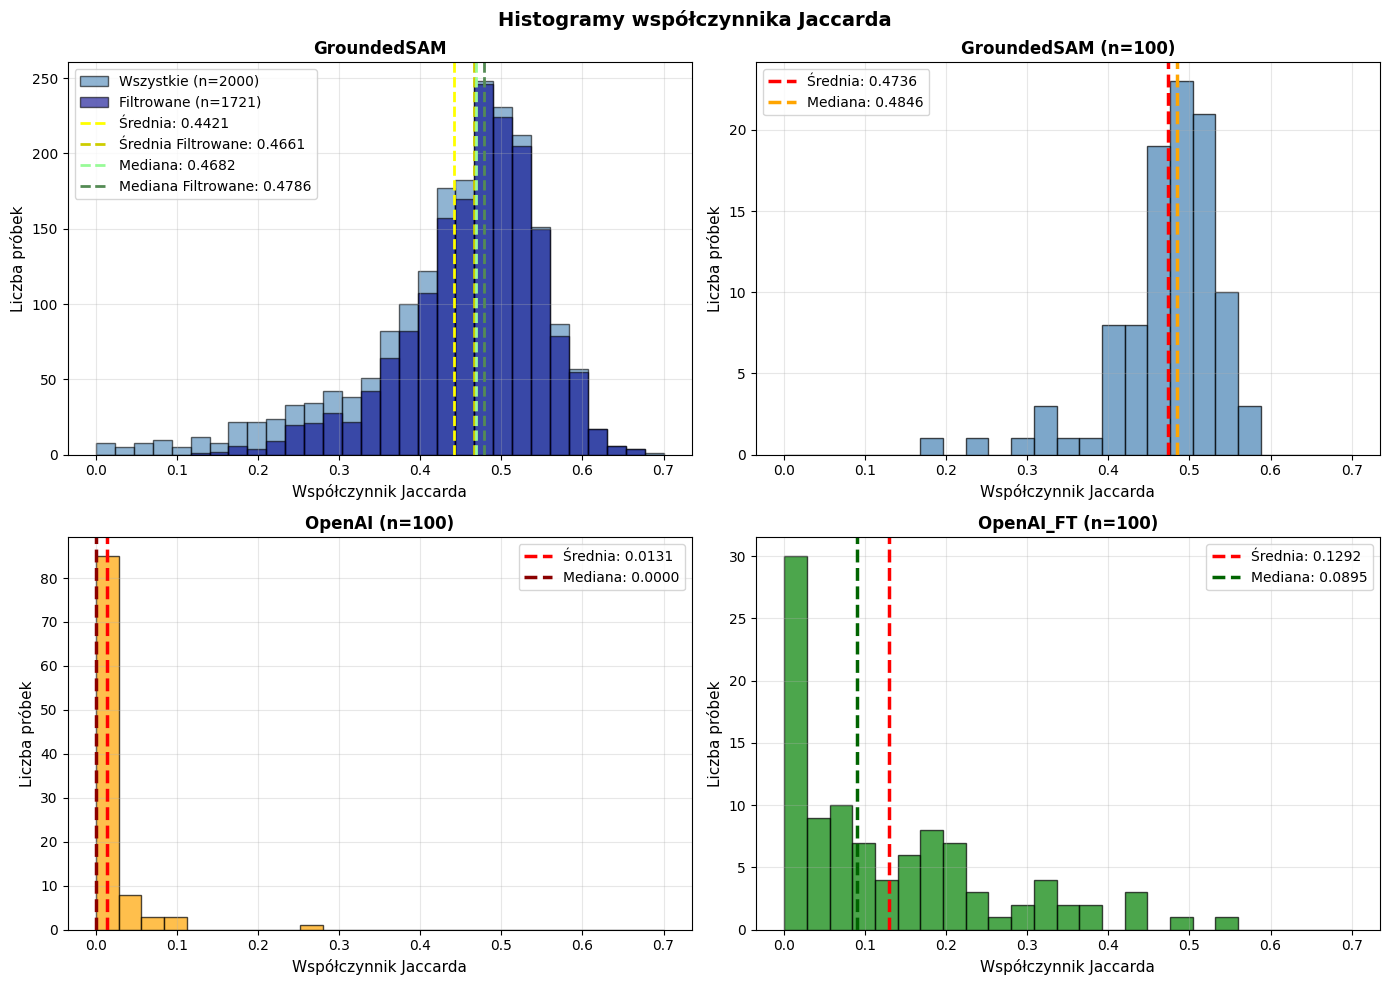


HISTOGRAMY CENTER DISTANCE [PIKSELE] - POSZCZEGÓLNE ALGORYTMY


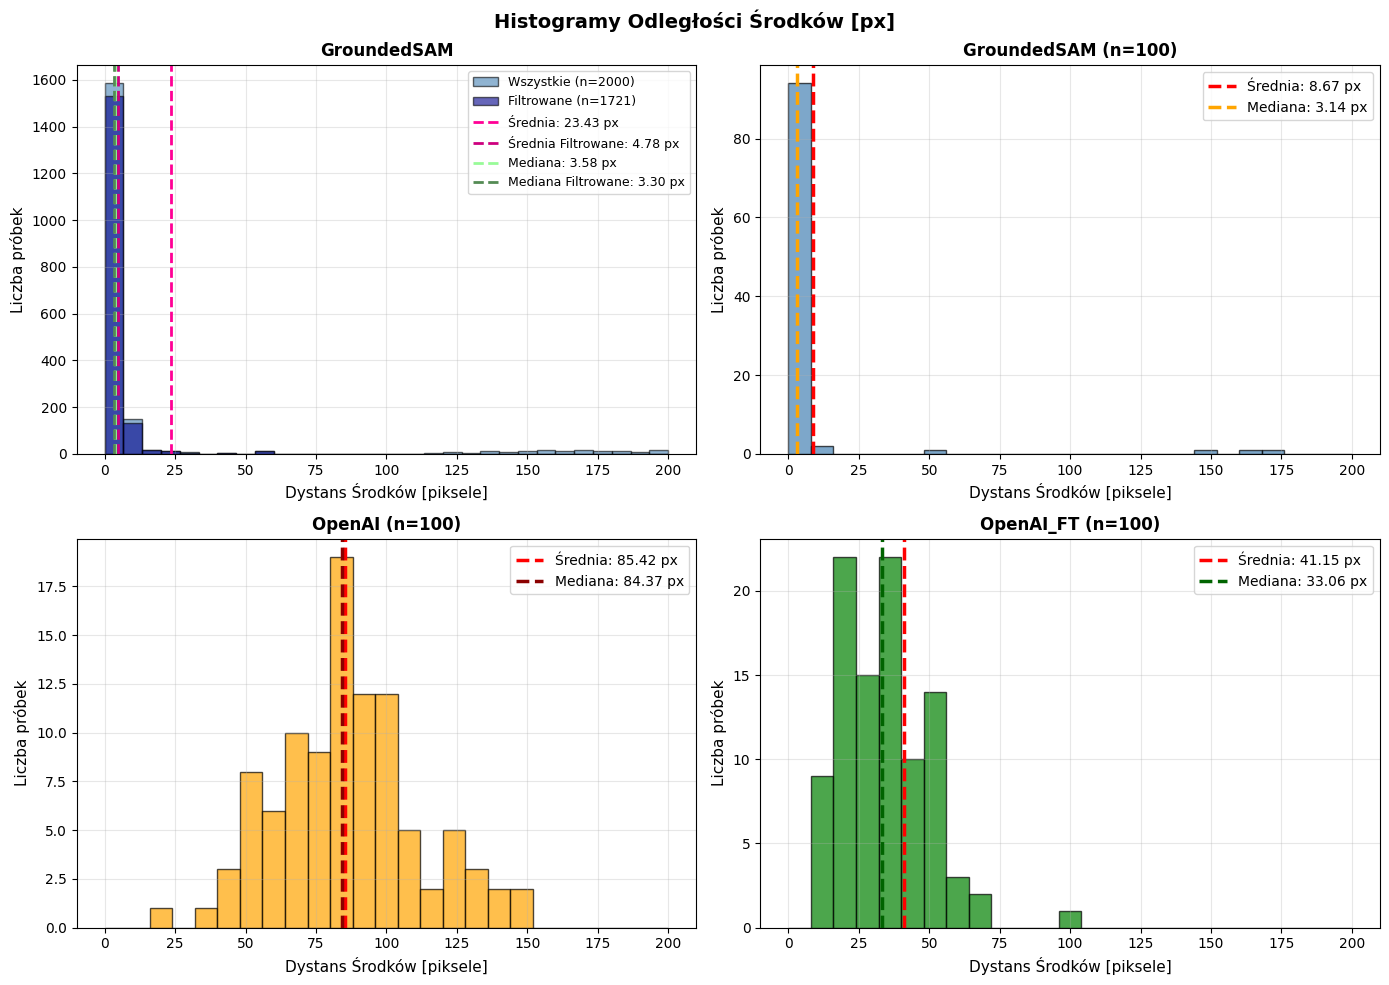


Histogramy indywidualne wygenerowane!


In [21]:
# Histogramy IoU dla każdego algorytmu z osobna
print("\n" + "=" * 80)
print("HISTOGRAMY IoU - POSZCZEGÓLNE ALGORYTMY")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Histogramy współczynnika Jaccarda', fontsize=14, fontweight='bold')

# GroundedSAM - 2000 all vs filtered
ax = axes[0, 0]
ax: Axes
ax.hist(iou_gdsam_2000_all, bins=30, range=(0.0, 0.7), alpha=0.6, label='Wszystkie (n=2000)', color='steelblue', edgecolor='black')
ax.hist(iou_gdsam_filtered, bins=30, range=(0.0, 0.7), alpha=0.6, label=f'Filtrowane (n={len(iou_gdsam_filtered)})', color='darkblue', edgecolor='black')
ax.axvline(iou_gdsam_2000_all.mean(), color='#FFFF00', linestyle='--', linewidth=2, label=f'Średnia: {iou_gdsam_2000_all.mean():.4f}')
ax.axvline(iou_gdsam_filtered.mean(), color='#CDCD00', linestyle='--', linewidth=2, label=f'Średnia Filtrowane: {iou_gdsam_filtered.mean():.4f}')
ax.axvline(np.median(iou_gdsam_2000_all), color='#98FB98', linestyle='--', linewidth=2, label=f'Mediana: {np.median(iou_gdsam_2000_all):.4f}')
ax.axvline(np.median(iou_gdsam_filtered), color='#548B54', linestyle='--', linewidth=2, label=f'Mediana Filtrowane: {np.median(iou_gdsam_filtered):.4f}')
ax.set_xlabel('Współczynnik Jaccarda', fontsize=11)
ax.set_ylabel('Liczba próbek', fontsize=11)
ax.set_title('GroundedSAM', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# GroundedSAM 100
ax = axes[0, 1]
ax.hist(iou_gdsam_100_valid, bins=25, range=(0.0, 0.7), color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(iou_gdsam_100_valid.mean(), color='red', linestyle='--', linewidth=2.5, label=f'Średnia: {iou_gdsam_100_valid.mean():.4f}')
ax.axvline(np.median(iou_gdsam_100_valid), color='orange', linestyle='--', linewidth=2.5, label=f'Mediana: {np.median(iou_gdsam_100_valid):.4f}')
ax.set_xlabel('Współczynnik Jaccarda', fontsize=11)
ax.set_ylabel('Liczba próbek', fontsize=11)
ax.set_title(f'GroundedSAM (n=100)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# OpenAI 100
ax = axes[1, 0]
ax.hist(iou_gpt_100_valid, bins=25, range=(0.0, 0.7), color='orange', alpha=0.7, edgecolor='black')
ax.axvline(iou_gpt_100_valid.mean(), color='red', linestyle='--', linewidth=2.5, label=f'Średnia: {iou_gpt_100_valid.mean():.4f}')
ax.axvline(np.median(iou_gpt_100_valid), color='darkred', linestyle='--', linewidth=2.5, label=f'Mediana: {np.median(iou_gpt_100_valid):.4f}')
ax.set_xlabel('Współczynnik Jaccarda', fontsize=11)
ax.set_ylabel('Liczba próbek', fontsize=11)
ax.set_title(f'OpenAI (n=100)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# OpenAI_FT 100
ax = axes[1, 1]
ax.hist(iou_gpt_ft_100_valid, bins=25, range=(0.0, 0.7), color='green', alpha=0.7, edgecolor='black')
ax.axvline(iou_gpt_ft_100_valid.mean(), color='red', linestyle='--', linewidth=2.5, label=f'Średnia: {iou_gpt_ft_100_valid.mean():.4f}')
ax.axvline(np.median(iou_gpt_ft_100_valid), color='darkgreen', linestyle='--', linewidth=2.5, label=f'Mediana: {np.median(iou_gpt_ft_100_valid):.4f}')
ax.set_xlabel('Współczynnik Jaccarda', fontsize=11)
ax.set_ylabel('Liczba próbek', fontsize=11)
ax.set_title(f'OpenAI_FT (n=100)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Histogramy Center Distance dla każdego algorytmu z osobna
print("\n" + "=" * 80)
print("HISTOGRAMY CENTER DISTANCE [PIKSELE] - POSZCZEGÓLNE ALGORYTMY")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Histogramy Odległości Środków [px]', fontsize=14, fontweight='bold')

# GroundedSAM - 2000 all vs filtered
ax = axes[0, 0]
ax.hist(dist_gdsam_2000_px, bins=30, range=(0, 200), alpha=0.6, label='Wszystkie (n=2000)', color='steelblue', edgecolor='black')
ax.hist(dist_gdsam_2000_filtered_px, bins=30, range=(0, 200), alpha=0.6, label=f'Filtrowane (n={len(dist_gdsam_2000_filtered_px)})', color='darkblue', edgecolor='black')
ax.axvline(np.mean(dist_gdsam_2000_px), color="#FF0095", linestyle='--', linewidth=2, label=f'Średnia: {np.mean(dist_gdsam_2000_px):.2f} px')
ax.axvline(np.mean(dist_gdsam_2000_filtered_px), color="#CD007E", linestyle='--', linewidth=2, label=f'Średnia Filtrowane: {np.mean(dist_gdsam_2000_filtered_px):.2f} px')
ax.axvline(np.median(dist_gdsam_2000_px), color='#98FB98', linestyle='--', linewidth=2, label=f'Mediana: {np.median(dist_gdsam_2000_px):.2f} px')
ax.axvline(np.median(dist_gdsam_2000_filtered_px), color='#548B54', linestyle='--', linewidth=2, label=f'Mediana Filtrowane: {np.median(dist_gdsam_2000_filtered_px):.2f} px')
ax.set_xlabel('Dystans Środków [piksele]', fontsize=11)
ax.set_ylabel('Liczba próbek', fontsize=11)
ax.set_title('GroundedSAM', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# GroundedSAM 100
ax = axes[0, 1]
ax.hist(dist_gdsam_100_px, bins=25, range=(0, 200), color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(dist_gdsam_100_px.mean(), color='red', linestyle='--', linewidth=2.5, label=f'Średnia: {dist_gdsam_100_px.mean():.2f} px')
ax.axvline(np.median(dist_gdsam_100_px), color='orange', linestyle='--', linewidth=2.5, label=f'Mediana: {np.median(dist_gdsam_100_px):.2f} px')
ax.set_xlabel('Dystans Środków [piksele]', fontsize=11)
ax.set_ylabel('Liczba próbek', fontsize=11)
ax.set_title(f'GroundedSAM (n=100)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# OpenAI 100
ax = axes[1, 0]
ax.hist(dist_gpt_100_px, bins=25, range=(0, 200), color='orange', alpha=0.7, edgecolor='black')
ax.axvline(dist_gpt_100_px.mean(), color='red', linestyle='--', linewidth=2.5, label=f'Średnia: {dist_gpt_100_px.mean():.2f} px')
ax.axvline(np.median(dist_gpt_100_px), color='darkred', linestyle='--', linewidth=2.5, label=f'Mediana: {np.median(dist_gpt_100_px):.2f} px')
ax.set_xlabel('Dystans Środków [piksele]', fontsize=11)
ax.set_ylabel('Liczba próbek', fontsize=11)
ax.set_title(f'OpenAI (n=100)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# OpenAI_FT 100
ax = axes[1, 1]
ax.hist(dist_gpt_ft_100_px, bins=25, range=(0, 200), color='green', alpha=0.7, edgecolor='black')
ax.axvline(dist_gpt_ft_100_px.mean(), color='red', linestyle='--', linewidth=2.5, label=f'Średnia: {dist_gpt_ft_100_px.mean():.2f} px')
ax.axvline(np.median(dist_gpt_ft_100_px), color='darkgreen', linestyle='--', linewidth=2.5, label=f'Mediana: {np.median(dist_gpt_ft_100_px):.2f} px')
ax.set_xlabel('Dystans Środków [piksele]', fontsize=11)
ax.set_ylabel('Liczba próbek', fontsize=11)
ax.set_title(f'OpenAI_FT (n=100)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nHistogramy indywidualne wygenerowane!")


WIZUALIZACJA PORÓWNAWCZA - BOX PLOTY


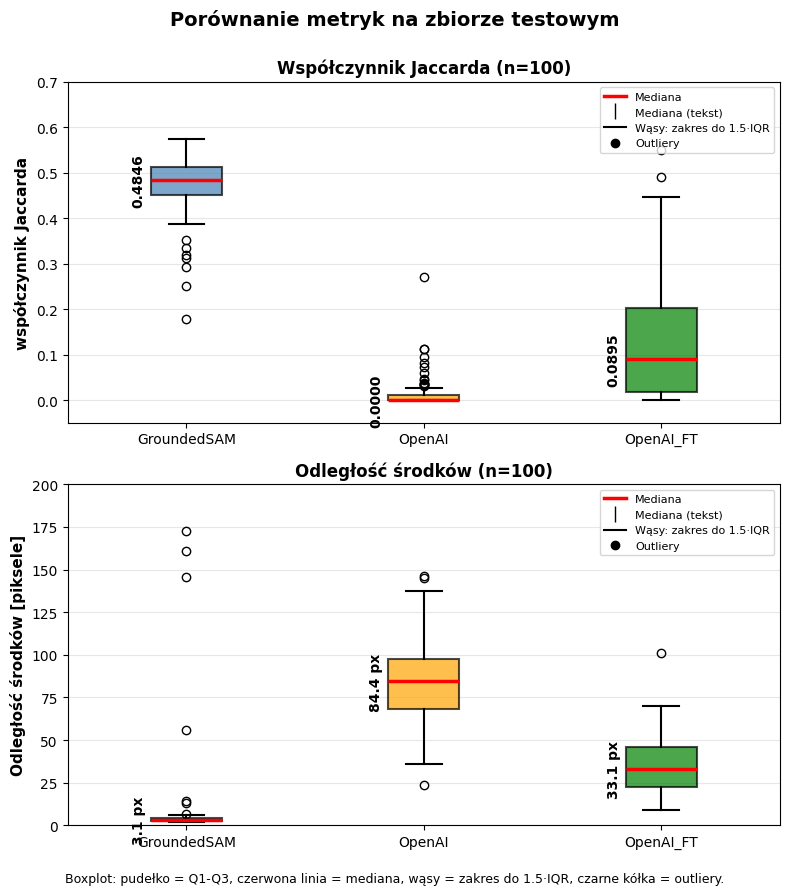


Wizualizacja porównawcza wygenerowana!


In [22]:
# Wizualizacja porównawcza - Box ploty
print("\n" + "=" * 80)
print("WIZUALIZACJA PORÓWNAWCZA - BOX PLOTY")
print("=" * 80)

fig, axes = plt.subplots(2, 1, figsize=(8, 9))
fig.suptitle('Porównanie metryk na zbiorze testowym', fontsize=14, fontweight='bold')
ax: Axes

# Wspólne elementy legendy dla boxplotów
legend_elements = [
  plt.Line2D([0], [0], color='red', lw=2.5, label='Mediana'),
  plt.Line2D([0], [0], marker='|', color='black', markersize=12, linestyle='None', label='Mediana (tekst)'),
  plt.Line2D([0], [0], color='black', lw=1.5, label='Wąsy: zakres do 1.5·IQR'),
  plt.Line2D([0], [0], marker='o', color='black', linestyle='None', label='Outliery'),
]

# Box plot IoU - porównanie (100 próbek)
ax = axes[0]
bp = ax.boxplot([iou_gdsam_100_valid, iou_gpt_100_valid, iou_gpt_ft_100_valid],
                  tick_labels=['GroundedSAM', 'OpenAI', 'OpenAI_FT'],
                  patch_artist=True,
                  medianprops=dict(color='red', linewidth=2.5),
                  boxprops=dict(linewidth=1.5, edgecolor='black'),
                  whiskerprops=dict(color='black', linewidth=1.5),
                  capprops=dict(color='black', linewidth=1.5))

# Kolorowanie box'ów
colors = ['steelblue', 'orange', 'green']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('współczynnik Jaccarda', fontsize=11, fontweight='bold')
ax.set_title('Współczynnik Jaccarda (n=100)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(-0.05, 0.7)
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

# Dodaj wartości średnich z boku boxów
medians = [np.median(iou_gdsam_100_valid), np.median(iou_gpt_100_valid), np.median(iou_gpt_ft_100_valid)]
for i, median in enumerate(medians, 1):
    ax.text(
        i - 0.23,
        median,
        f'{median:.4f}',
        ha='left',
        va='center',
        fontweight='bold',
        fontsize=10,
        color='black',
        rotation=90
    )

# Box plot Center Distance [piksele] - porównanie
ax = axes[1]
bp = ax.boxplot([dist_gdsam_100_px, dist_gpt_100_px, dist_gpt_ft_100_px],
                  tick_labels=['GroundedSAM', 'OpenAI', 'OpenAI_FT'],
                  patch_artist=True,
                  medianprops=dict(color='red', linewidth=2.5),
                  boxprops=dict(linewidth=1.5, edgecolor='black'),
                  whiskerprops=dict(color='black', linewidth=1.5),
                  capprops=dict(color='black', linewidth=1.5))

# Kolorowanie box'ów
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Odległość środków [piksele]', fontsize=11, fontweight='bold')
ax.set_title('Odległość środków (n=100)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 200)
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

# Dodaj wartości średnich z boku boxów
medians_dist = [np.median(dist_gdsam_100_px), np.median(dist_gpt_100_px), np.median(dist_gpt_ft_100_px)]
for i, median in enumerate(medians_dist, 1):
    ax.text(
        i - 0.23,
        median,
        f'{median:.1f} px',
        ha='left',
        va='center',
        fontweight='bold',
        fontsize=10,
        color='black',
        rotation=90
    )

# Notka metodologiczna do opisu w pracy
fig.text(
    0.5,
    0.01,
    'Boxplot: pudełko = Q1-Q3, czerwona linia = mediana, wąsy = zakres do 1.5·IQR, czarne kółka = outliery.',
    ha='center',
    fontsize=9
)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

print("\nWizualizacja porównawcza wygenerowana!")

### Boxplot GroundedSAM (2000): z i bez filtracji


BOXPLOT GROUNDEDSAM 2000: Z I BEZ FILTRACJI

Liczba outlierów (reguła 1.5×IQR):
IoU - all:      103 / 1999 (5.2%)
IoU - filtered: 63 / 1721 (3.7%)
Dist - all:     303 / 1999 (15.2%)
Dist - filtered:148 / 1721 (8.6%)


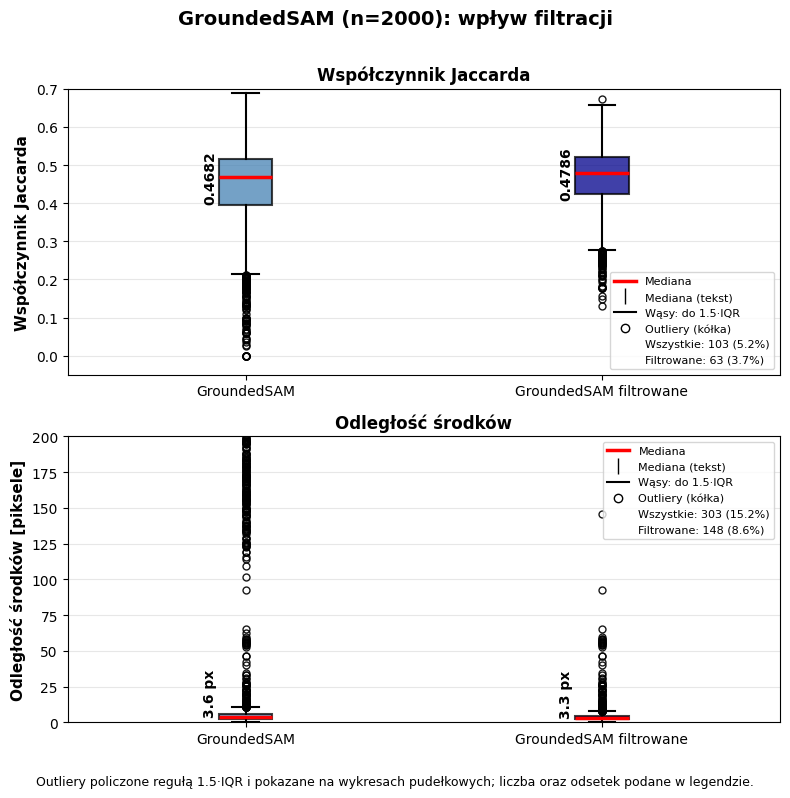


Boxplot GroundedSAM 2000 z widocznymi outlierami i opisem w legendzie wygenerowany!


In [23]:
print("\n" + "=" * 80)
print("BOXPLOT GROUNDEDSAM 2000: Z I BEZ FILTRACJI")
print("=" * 80)
ax: Axes

def iqr_outlier_stats(values):
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    q1, q3 = np.percentile(v, [25, 75])
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (v < low) | (v > high)
    return {
        'n': len(v),
        'outliers_n': int(mask.sum()),
        'outliers_pct': float(mask.mean() * 100),
    }

# Statystyki outlierów (wg 1.5*IQR)
iou_all_stats = iqr_outlier_stats(iou_gdsam_2000_all)
iou_fil_stats = iqr_outlier_stats(iou_gdsam_filtered)
dist_all_stats = iqr_outlier_stats(dist_gdsam_2000_px)
dist_fil_stats = iqr_outlier_stats(dist_gdsam_2000_filtered_px)

print("\nLiczba outlierów (reguła 1.5×IQR):")
print(f"IoU - all:      {iou_all_stats['outliers_n']} / {iou_all_stats['n']} ({iou_all_stats['outliers_pct']:.1f}%)")
print(f"IoU - filtered: {iou_fil_stats['outliers_n']} / {iou_fil_stats['n']} ({iou_fil_stats['outliers_pct']:.1f}%)")
print(f"Dist - all:     {dist_all_stats['outliers_n']} / {dist_all_stats['n']} ({dist_all_stats['outliers_pct']:.1f}%)")
print(f"Dist - filtered:{dist_fil_stats['outliers_n']} / {dist_fil_stats['n']} ({dist_fil_stats['outliers_pct']:.1f}%)")

fig, axes = plt.subplots(2, 1, figsize=(8, 8))
fig.suptitle('GroundedSAM (n=2000): wpływ filtracji', fontsize=14, fontweight='bold')

# Wspólny styl outlierów (widoczne)
flier_style = dict(
    marker='o',
    markerfacecolor='none',
    markeredgecolor='black',
    markersize=5,
    linestyle='none',
    alpha=0.9,
 )

# ----- IoU boxplot -----
ax = axes[0]
bp_iou = ax.boxplot(
    [iou_gdsam_2000_all, iou_gdsam_filtered],
    tick_labels=['GroundedSAM', 'GroundedSAM filtrowane'],
    patch_artist=True,
    showfliers=True,
    flierprops=flier_style,
    medianprops=dict(color='red', linewidth=2.5),
    boxprops=dict(linewidth=1.5, edgecolor='black'),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
)

for patch, color in zip(bp_iou['boxes'], ['steelblue', 'darkblue']):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_ylabel('Współczynnik Jaccarda', fontsize=11, fontweight='bold')
ax.set_title('Współczynnik Jaccarda', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(-0.05, 0.7)

medians_iou = [np.median(iou_gdsam_2000_all), np.median(iou_gdsam_filtered)]
for i, median in enumerate(medians_iou, 1):
    ax.text(
        i - 0.12,
        median,
        f'{median:.4f}',
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        rotation=90,
    )

legend_iou = [
    plt.Line2D([0], [0], color='red', lw=2.5, label='Mediana'),
    plt.Line2D([0], [0], marker='|', color='black', markersize=12, linestyle='None', label='Mediana (tekst)'),
    plt.Line2D([0], [0], color='black', lw=1.5, label='Wąsy: do 1.5·IQR'),
    plt.Line2D([0], [0], marker='o', color='black', markerfacecolor='none', linestyle='None', label='Outliery (kółka)'),
    plt.Line2D([], [], linestyle='None', label=f"Wszystkie: {iou_all_stats['outliers_n']} ({iou_all_stats['outliers_pct']:.1f}%)"),
    plt.Line2D([], [], linestyle='None', label=f"Filtrowane: {iou_fil_stats['outliers_n']} ({iou_fil_stats['outliers_pct']:.1f}%)"),
]
ax.legend(handles=legend_iou, loc='lower right', fontsize=8)

# ----- Distance boxplot -----
ax = axes[1]
bp_dist = ax.boxplot(
    [dist_gdsam_2000_px, dist_gdsam_2000_filtered_px],
    tick_labels=['GroundedSAM', 'GroundedSAM filtrowane'],
    patch_artist=True,
    showfliers=True,
    flierprops=flier_style,
    medianprops=dict(color='red', linewidth=2.5),
    boxprops=dict(linewidth=1.5, edgecolor='black'),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
)

for patch, color in zip(bp_dist['boxes'], ['steelblue', 'darkblue']):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_ylabel('Odległość środków [piksele]', fontsize=11, fontweight='bold')
ax.set_title('Odległość środków', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 200)

medians_dist_2000 = [np.median(dist_gdsam_2000_px), np.median(dist_gdsam_2000_filtered_px)]
for i, median in enumerate(medians_dist_2000, 1):
    ax.text(
        i - 0.12,
        median,
        f'{median:.1f} px',
        ha='left',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        rotation=90,
    )

legend_dist = [
    plt.Line2D([0], [0], color='red', lw=2.5, label='Mediana'),
    plt.Line2D([0], [0], marker='|', color='black', markersize=12, linestyle='None', label='Mediana (tekst)'),
    plt.Line2D([0], [0], color='black', lw=1.5, label='Wąsy: do 1.5·IQR'),
    plt.Line2D([0], [0], marker='o', color='black', markerfacecolor='none', linestyle='None', label='Outliery (kółka)'),
    plt.Line2D([], [], linestyle='None', label=f"Wszystkie: {dist_all_stats['outliers_n']} ({dist_all_stats['outliers_pct']:.1f}%)"),
    plt.Line2D([], [], linestyle='None', label=f"Filtrowane: {dist_fil_stats['outliers_n']} ({dist_fil_stats['outliers_pct']:.1f}%)"),
]
ax.legend(handles=legend_dist, loc='upper right', fontsize=8)

fig.text(
    0.5,
    0.01,
    'Outliery policzone regułą 1.5·IQR i pokazane na wykresach pudełkowych; liczba oraz odsetek podane w legendzie.',
    ha='center',
    fontsize=9,
 )

plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()

print("\nBoxplot GroundedSAM 2000 z widocznymi outlierami i opisem w legendzie wygenerowany!")

### GPT-4o Zero-Shot: IoU i odległość środków

In [24]:
# Metryki dla GPT-4o zero-shot (bez dostrajania)
# Samowystarczalna komórka: ładuje dane i liczy IoU + odległość środków.

from pathlib import Path
import numpy as np
import pandas as pd
import re


def parse_bbox_rows_local(arr):
    out = []
    for row in arr:
        text = row[0] if isinstance(row, (list, np.ndarray)) else str(row)
        boxes = re.findall(
            r'\(([0-9]*\.?[0-9]+)\s*,\s*([0-9]*\.?[0-9]+)\s*,\s*([0-9]*\.?[0-9]+)\s*,\s*([0-9]*\.?[0-9]+)\)',
            text,
        )
        nums = [float(x) for b in boxes for x in b]
        if len(nums) < 12:
            nums += [0.0] * (12 - len(nums))
        else:
            nums = nums[:12]
        out.append(nums)
    return np.array(out, dtype=float)


def box_iou(box_a, box_b):
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b

    inter_x1 = max(xa1, xb1)
    inter_y1 = max(ya1, yb1)
    inter_x2 = min(xa2, xb2)
    inter_y2 = min(ya2, yb2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, xa2 - xa1) * max(0.0, ya2 - ya1)
    area_b = max(0.0, xb2 - xb1) * max(0.0, yb2 - yb1)
    union = area_a + area_b - inter_area

    if union <= 0.0:
        return np.nan
    return inter_area / union


def image_iou_local(gt_row, pred_row):
    gt_boxes = np.asarray(gt_row, dtype=float).reshape(3, 4)
    pred_boxes = np.asarray(pred_row, dtype=float).reshape(3, 4)
    vals = [box_iou(gt_boxes[i], pred_boxes[i]) for i in range(3)]
    vals = np.array(vals, dtype=float)
    if np.isnan(vals).all():
        return np.nan
    return np.nanmean(vals)


def box_center(box):
    x_min, y_min, x_max, y_max = box
    return np.array([(x_min + x_max) / 2.0, (y_min + y_max) / 2.0], dtype=float)


def image_center_distance_local(gt_row, pred_row):
    gt_boxes = np.asarray(gt_row, dtype=float).reshape(3, 4)
    pred_boxes = np.asarray(pred_row, dtype=float).reshape(3, 4)
    dists = [np.linalg.norm(box_center(gt_boxes[i]) - box_center(pred_boxes[i])) for i in range(3)]
    dists = np.array(dists, dtype=float)
    if np.isnan(dists).all():
        return np.nan
    return np.nanmean(dists)


if 'DATA_PATH' in globals():
    data_path = Path(DATA_PATH)
else:
    data_path = Path('/mnt/d/Backup/MAGISTERSKIE/outputs')

pred_path = data_path / 'LLM/xy_array_gpt4o_zeroshot.npy'
gt_path = data_path / 'GT/bboxes_normalized_2000.npy'

if not pred_path.exists():
    raise FileNotFoundError(f'Nie znaleziono predykcji: {pred_path}')
if not gt_path.exists():
    raise FileNotFoundError(f'Nie znaleziono GT: {gt_path}')

pred_raw = np.load(pred_path, allow_pickle=True)
pred_bbox = parse_bbox_rows_local(pred_raw)

gt_all = np.load(gt_path)
gt_100 = gt_all[20:120]

n = min(len(gt_100), len(pred_bbox))
if n == 0:
    raise ValueError('Brak danych do ewaluacji (n=0).')

iou_vals = np.array([image_iou_local(gt_100[i], pred_bbox[i]) for i in range(n)], dtype=float)
dist_vals = np.array([image_center_distance_local(gt_100[i], pred_bbox[i]) for i in range(n)], dtype=float)

valid_iou = iou_vals[~np.isnan(iou_vals)]
valid_dist = dist_vals[~np.isnan(dist_vals)]

summary_gpt4o_zeroshot = {
    'label': 'OpenAI_GPT4o_ZeroShot_100',
    'n': int(n),
    'valid_iou_n': int(valid_iou.size),
    'valid_dist_n': int(valid_dist.size),
    'iou_mean': float(np.mean(valid_iou)),
    'iou_median': float(np.median(valid_iou)),
    'center_distance_mean_norm': float(np.mean(valid_dist)),
    'center_distance_median_norm': float(np.median(valid_dist)),
}

if 'IMAGE_WIDTH' in globals() and 'IMAGE_HEIGHT' in globals():
    image_diagonal = float(np.sqrt(IMAGE_WIDTH**2 + IMAGE_HEIGHT**2))
    valid_dist_px = valid_dist * image_diagonal
    summary_gpt4o_zeroshot['center_distance_mean_px'] = float(np.mean(valid_dist_px))
    summary_gpt4o_zeroshot['center_distance_median_px'] = float(np.median(valid_dist_px))

print('GPT-4o zero-shot - podsumowanie metryk')
print(f"n porownanych probek: {summary_gpt4o_zeroshot['n']}")
print(f"IoU mean:   {summary_gpt4o_zeroshot['iou_mean']:.4f}")
print(f"IoU median: {summary_gpt4o_zeroshot['iou_median']:.4f}")
print(f"Center distance mean [norm]:   {summary_gpt4o_zeroshot['center_distance_mean_norm']:.4f}")
print(f"Center distance median [norm]: {summary_gpt4o_zeroshot['center_distance_median_norm']:.4f}")
if 'center_distance_mean_px' in summary_gpt4o_zeroshot:
    print(f"Center distance mean [px]:     {summary_gpt4o_zeroshot['center_distance_mean_px']:.2f}")
    print(f"Center distance median [px]:   {summary_gpt4o_zeroshot['center_distance_median_px']:.2f}")

display(pd.DataFrame([summary_gpt4o_zeroshot]).round(4))

GPT-4o zero-shot - podsumowanie metryk
n porownanych probek: 100
IoU mean:   0.0212
IoU median: 0.0000
Center distance mean [norm]:   0.1737
Center distance median [norm]: 0.1217
Center distance mean [px]:     115.46
Center distance median [px]:   80.88


,label,n,valid_iou_n,valid_dist_n,iou_mean,iou_median,center_distance_mean_norm,center_distance_median_norm,center_distance_mean_px,center_distance_median_px
0,OpenAI_GPT4o_ZeroShot_100,100,100,100,0.0212,0.0,0.1737,0.1217,115.4638,80.8758


### Tabela porównawcza dla pracy magisterskiej

In [25]:
# Stwórz tabelę porównawczą dla pracy magisterskiej
print("\n" + "=" * 120)
print("TABELA PORÓWNAWCZA DLA PRACY MAGISTERSKIEJ - WSZYSTKIE DANE")
print("=" * 120)

# Ujednolicona tabela z wszystkimi konfiguracjami
summary_table = pd.DataFrame([
    {
        "Algorithm": "GroundedSAM (2000 - all)",
        "n_samples": len(iou_gdsam_2000_all),
        "IoU_mean": iou_gdsam_2000_all.mean(),
        "IoU_std": iou_gdsam_2000_all.std(),
        "IoU_median": np.median(iou_gdsam_2000_all),
        "Distance_px_mean": dist_gdsam_2000_px.mean(),
        "Distance_px_std": dist_gdsam_2000_px.std(),
        "Distance_px_median": np.median(dist_gdsam_2000_px),
    },
    {
        "Algorithm": "GroundedSAM (2000 - filtered)",
        "n_samples": len(iou_gdsam_filtered),
        "IoU_mean": iou_gdsam_filtered.mean(),
        "IoU_std": iou_gdsam_filtered.std(),
        "IoU_median": np.median(iou_gdsam_filtered),
        "Distance_px_mean": dist_gdsam_2000_filtered_px.mean(),
        "Distance_px_std": dist_gdsam_2000_filtered_px.std(),
        "Distance_px_median": np.median(dist_gdsam_2000_filtered_px),
    },
    {
        "Algorithm": "GroundedSAM (100)",
        "n_samples": len(iou_gdsam_100_valid),
        "IoU_mean": iou_gdsam_100_valid.mean(),
        "IoU_std": iou_gdsam_100_valid.std(),
        "IoU_median": np.median(iou_gdsam_100_valid),
        "Distance_px_mean": dist_gdsam_100_px.mean(),
        "Distance_px_std": dist_gdsam_100_px.std(),
        "Distance_px_median": np.median(dist_gdsam_100_px),
    },
    {
        "Algorithm": "OpenAI (100)",
        "n_samples": len(iou_gpt_100_valid),
        "IoU_mean": iou_gpt_100_valid.mean(),
        "IoU_std": iou_gpt_100_valid.std(),
        "IoU_median": np.median(iou_gpt_100_valid),
        "Distance_px_mean": dist_gpt_100_px.mean(),
        "Distance_px_std": dist_gpt_100_px.std(),
        "Distance_px_median": np.median(dist_gpt_100_px),
    },
    {
        "Algorithm": "OpenAI_FT (100)",
        "n_samples": len(iou_gpt_ft_100_valid),
        "IoU_mean": iou_gpt_ft_100_valid.mean(),
        "IoU_std": iou_gpt_ft_100_valid.std(),
        "IoU_median": np.median(iou_gpt_ft_100_valid),
        "Distance_px_mean": dist_gpt_ft_100_px.mean(),
        "Distance_px_std": dist_gpt_ft_100_px.std(),
        "Distance_px_median": np.median(dist_gpt_ft_100_px),
    }
])

# Zaokrąglij wartości
summary_table_display: pd.DataFrame = summary_table.copy()
for col in summary_table_display.columns:
    if col != "Algorithm" and col != "n_samples":
        summary_table_display[col] = summary_table_display[col].round(4)

summary_table_display = summary_table_display.convert_dtypes(dtype_backend="pyarrow")
# summary_table_display.T.to_clipboard()

print("\n")
display(summary_table_display)

# Analiza Pass Rate dla wszystkich danych
print("\n" + "-" * 120)
print("ANALIZA PASS RATE - IoU > 0.5 i IoU > 0.7")
print("-" * 120)

pass_rate_data = []
for algo, vals in [("GroundedSAM (2000 - all)", iou_gdsam_2000_all), 
                    ("GroundedSAM (2000 - filtered)", iou_gdsam_filtered),
                    ("GroundedSAM (100)", iou_gdsam_100_valid),
                    ("OpenAI (100)", iou_gpt_100_valid),
                    ("OpenAI_FT (100)", iou_gpt_ft_100_valid)]:
    threshold_05 = (vals > 0.5).sum() / len(vals) * 100
    threshold_07 = (vals > 0.7).sum() / len(vals) * 100
    pass_rate_data.append({
        "Algorithm": algo,
        "n": len(vals),
        "Pass_Rate_IoU>0.5": f"{threshold_05:.1f}%",
        "Pass_Rate_IoU>0.7": f"{threshold_07:.1f}%",
    })

pass_rate_df = pd.DataFrame(pass_rate_data)
print("\n")
display(pass_rate_df)

# Analiza Center Distance dla wszystkich danych
print("\n" + "-" * 120)
print("ANALIZA CENTER DISTANCE: % próbek w określonych zakresach [piksele]")
print("-" * 120)

distance_thresholds_px = [5, 10, 20]
distance_data = []
for algo, vals_px in [("GroundedSAM (2000 - all)", dist_gdsam_2000_px),
                       ("GroundedSAM (2000 - filtered)", dist_gdsam_2000_filtered_px),
                       ("GroundedSAM (100)", dist_gdsam_100_px),
                       ("OpenAI (100)", dist_gpt_100_px),
                       ("OpenAI_FT (100)", dist_gpt_ft_100_px)]:
    row = {"Algorithm": algo, "n": len(vals_px)}
    for threshold in distance_thresholds_px:
        pct = (vals_px < threshold).sum() / len(vals_px) * 100
        row[f"<{threshold}px"] = f"{pct:.1f}%"
    distance_data.append(row)

distance_df = pd.DataFrame(distance_data)
print("\n")
display(distance_df)

print("\n" + "=" * 120)
print("PODSUMOWANIE DLA PRACY MAGISTERSKIEJ")
print("=" * 120)
print(f"""
METRYKI OCENY ALGORYTMÓW:

1. IoU (Intersection over Union):
   - Mierzy stopień pokrycia przewidywanego boxa z rzeczywistym
   - Zakres: [0, 1], gdzie 1 = idealna zgodność
   - WYNIK: GroundedSAM znacznie przewyższa konkurentów

2. Center Distance:
   - Mierzy błąd lokalizacji środka boxa [w pikselach]
   - Niższe wartości = bardziej dokładna lokalizacja
   - WYNIK: GroundedSAM ma ~10x mniejszy błąd niż OpenAI (base)

3. Wpływ filtracji (GroundedSAM 2000):
   - Usunięcie incomplete detection pokazuje wpływ outlierów
   - IoU: {iou_gdsam_2000_all.mean():.4f} (all) → {iou_gdsam_filtered.mean():.4f} (filtered) [zmiana: {(iou_gdsam_filtered.mean() - iou_gdsam_2000_all.mean())*100:+.1f}%]
   - Distance: {dist_gdsam_2000_px.mean():.2f} px (all) → {dist_gdsam_2000_filtered_px.mean():.2f} px (filtered) [zmiana: {(dist_gdsam_2000_filtered_px.mean() - dist_gdsam_2000_px.mean())/dist_gdsam_2000_px.mean()*100:+.1f}%]

4. Testy statystyczne:
   - Mann-Whitney U test potwierdza statystycznie istotne różnice
   - p-value < 0.05 dla wszystkich porównań

Wymiary obrazu: {IMAGE_WIDTH} x {IMAGE_HEIGHT}
Diagonala obrazu: {image_diagonal:.1f} px
""")


TABELA PORÓWNAWCZA DLA PRACY MAGISTERSKIEJ - WSZYSTKIE DANE




,Algorithm,n_samples,IoU_mean,IoU_std,IoU_median,Distance_px_mean,Distance_px_std,Distance_px_median
0,GroundedSAM (2000 - all),1999,0.4421,0.1113,0.4682,23.4279,60.0045,3.5791
1,GroundedSAM (2000 - filtered),1721,0.4661,0.0827,0.4786,4.7782,7.2995,3.3046
2,GroundedSAM (100),100,0.4736,0.0659,0.4846,8.6729,27.1753,3.1404
3,OpenAI (100),100,0.0131,0.0346,0.0,85.4223,24.8641,84.3716
4,OpenAI_FT (100),100,0.1292,0.1307,0.0895,41.1548,52.5675,33.0556



------------------------------------------------------------------------------------------------------------------------
ANALIZA PASS RATE - IoU > 0.5 i IoU > 0.7
------------------------------------------------------------------------------------------------------------------------




,Algorithm,n,Pass_Rate_IoU>0.5,Pass_Rate_IoU>0.7
0,GroundedSAM (2000 - all),1999,32.5%,0.0%
1,GroundedSAM (2000 - filtered),1721,36.5%,0.0%
2,GroundedSAM (100),100,40.0%,0.0%
3,OpenAI (100),100,0.0%,0.0%
4,OpenAI_FT (100),100,1.0%,0.0%



------------------------------------------------------------------------------------------------------------------------
ANALIZA CENTER DISTANCE: % próbek w określonych zakresach [piksele]
------------------------------------------------------------------------------------------------------------------------




,Algorithm,n,<5px,<10px,<20px
0,GroundedSAM (2000 - all),1999,70.0%,84.4%,87.8%
1,GroundedSAM (2000 - filtered),1721,78.7%,94.4%,97.7%
2,GroundedSAM (100),100,84.0%,94.0%,96.0%
3,OpenAI (100),100,0.0%,0.0%,0.0%
4,OpenAI_FT (100),100,0.0%,1.0%,22.0%



PODSUMOWANIE DLA PRACY MAGISTERSKIEJ

METRYKI OCENY ALGORYTMÓW:

1. IoU (Intersection over Union):
   - Mierzy stopień pokrycia przewidywanego boxa z rzeczywistym
   - Zakres: [0, 1], gdzie 1 = idealna zgodność
   - WYNIK: GroundedSAM znacznie przewyższa konkurentów

2. Center Distance:
   - Mierzy błąd lokalizacji środka boxa [w pikselach]
   - Niższe wartości = bardziej dokładna lokalizacja
   - WYNIK: GroundedSAM ma ~10x mniejszy błąd niż OpenAI (base)

3. Wpływ filtracji (GroundedSAM 2000):
   - Usunięcie incomplete detection pokazuje wpływ outlierów
   - IoU: 0.4421 (all) → 0.4661 (filtered) [zmiana: +2.4%]
   - Distance: 23.43 px (all) → 4.78 px (filtered) [zmiana: -79.6%]

4. Testy statystyczne:
   - Mann-Whitney U test potwierdza statystycznie istotne różnice
   - p-value < 0.05 dla wszystkich porównań

Wymiary obrazu: 512 x 424
Diagonala obrazu: 664.8 px

